# Switch-Bounded Load Blocks

Apply a Block Invariant Contract to the partition induced by opening all Controllable Switches and emit `switch_bounded_load_blocks.parquet`.

Each block must pass:
- **(B)** non-empty in load or substation PCC
- **(C)** confined to a single Bus Voltage Class
- **(D/E)** records `phi_max` and the union of per-bus phase sets
- **(F)** acyclic in the static line graph with all Controllable Switches open
- **(G)** records Block Voltage Source Reachability (`substation_pcc`, `gfm_eligible_der`,
 `both`, `pending_der_inventory`, or `none`)

B/C/D/E/F are hard failures. G is recorded and may return `pending_der_inventory` until
`der_inventory.parquet` is complete.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import display

from study_location import bootstrap
session = bootstrap()
location_root = session.location_root
repo_root = session.repo_root

# load Location Workspace config and standard grid paths.
from location_runtime import build_grid_paths
from location_runtime import load_runtime as load_config_runtime

config, paths = load_config_runtime(location_root / "config.yaml")
grid = build_grid_paths(config)
location_root = paths["location_root"]
location_name = paths["location_name"]
repo_root = paths["repo_root"]
for key in (
    "shift_cache",
    "opendss_root",
    "asset_registry",
    "augmented_artifacts",
    "onm_export",
    "figures",
):
    grid[key].mkdir(parents=True, exist_ok=True)


### Load Prerequisites

In [2]:
buses = pd.read_csv(grid["asset_registry"] / "buses.csv")
lines = pd.read_csv(grid["asset_registry"] / "lines.csv")
loads = pd.read_csv(grid["asset_registry"] / "loads.csv")
sources = pd.read_csv(grid["asset_registry"] / "sources.csv")
transformers = pd.read_csv(grid["asset_registry"] / "transformers.csv")
switches = pd.read_parquet(grid["augmented_artifacts"] / "controllable_switches.parquet")
der_inventory = pd.read_parquet(grid["augmented_artifacts"] / "der_inventory.parquet")
print(f"{len(switches)} switches, {len(der_inventory)} DER rows, {len(transformers)} transformers")

150 switches, 15 DER rows, 877 transformers


### Validate Block Invariant Contract

Open all switches and partition the network into blocks. Hard-fail on B/C/D/E/F
violations; record G with a `pending_der_inventory` status when DER assignment
is incomplete.

In [3]:
# build critical load, DER, switch, and block artifacts.
from power.resilience import build_blocks

blocks, validation_report = build_blocks(
    buses=buses,
    lines=lines,
    loads=loads,
    sources=sources,
    switches=switches,
    der_inventory=der_inventory,
    transformers=transformers,
    location_id=paths["location_name"],
)

print(f"Blocks: {len(blocks)}")
print(f"Invariant violations: {validation_report.get('violations', [])}")
display(pd.Series(validation_report.get("summary", {}), name="block_invariant_summary"))

Blocks: 192
Invariant violations: []


block_count 192
total_load_kw 47190.0
max_bus_count 314
voltage_source_reachability {'both': 5, 'gfm_eligible_der': 7, 'none': 143...
Name: block_invariant_summary, dtype: object

### Block Voltage Source Reachability Summary

In [4]:
# Distribution of Block Voltage Source Reachability across all blocks.
display(blocks["voltage_source_reachability"].value_counts().rename("block_count"))

voltage_source_reachability
none 143
substation_pcc 37
gfm_eligible_der 7
both 5
Name: block_count, dtype: int64

### Write Artifact

In [5]:
import json

out_path = grid["augmented_artifacts"] / "switch_bounded_load_blocks.parquet"
blocks.to_parquet(out_path, index=False)

report_path = grid["augmented_artifacts"] / "block_invariant_report.json"
report_path.write_text(json.dumps(validation_report, indent=2))

print(f"Wrote {len(blocks)} blocks to {out_path.relative_to(repo_root)}")
print(f"Validation report: {report_path.relative_to(repo_root)}")

Wrote 192 blocks to locations/marshfield/data/static/power_grid/smart_ds_compat/switch_bounded_load_blocks.parquet
Validation report: locations/marshfield/data/static/power_grid/smart_ds_compat/block_invariant_report.json


### Plot Block Review Figures

Render the full switch-bounded block hull plot and the Ocean Bluff / Brant Rock detailed plot


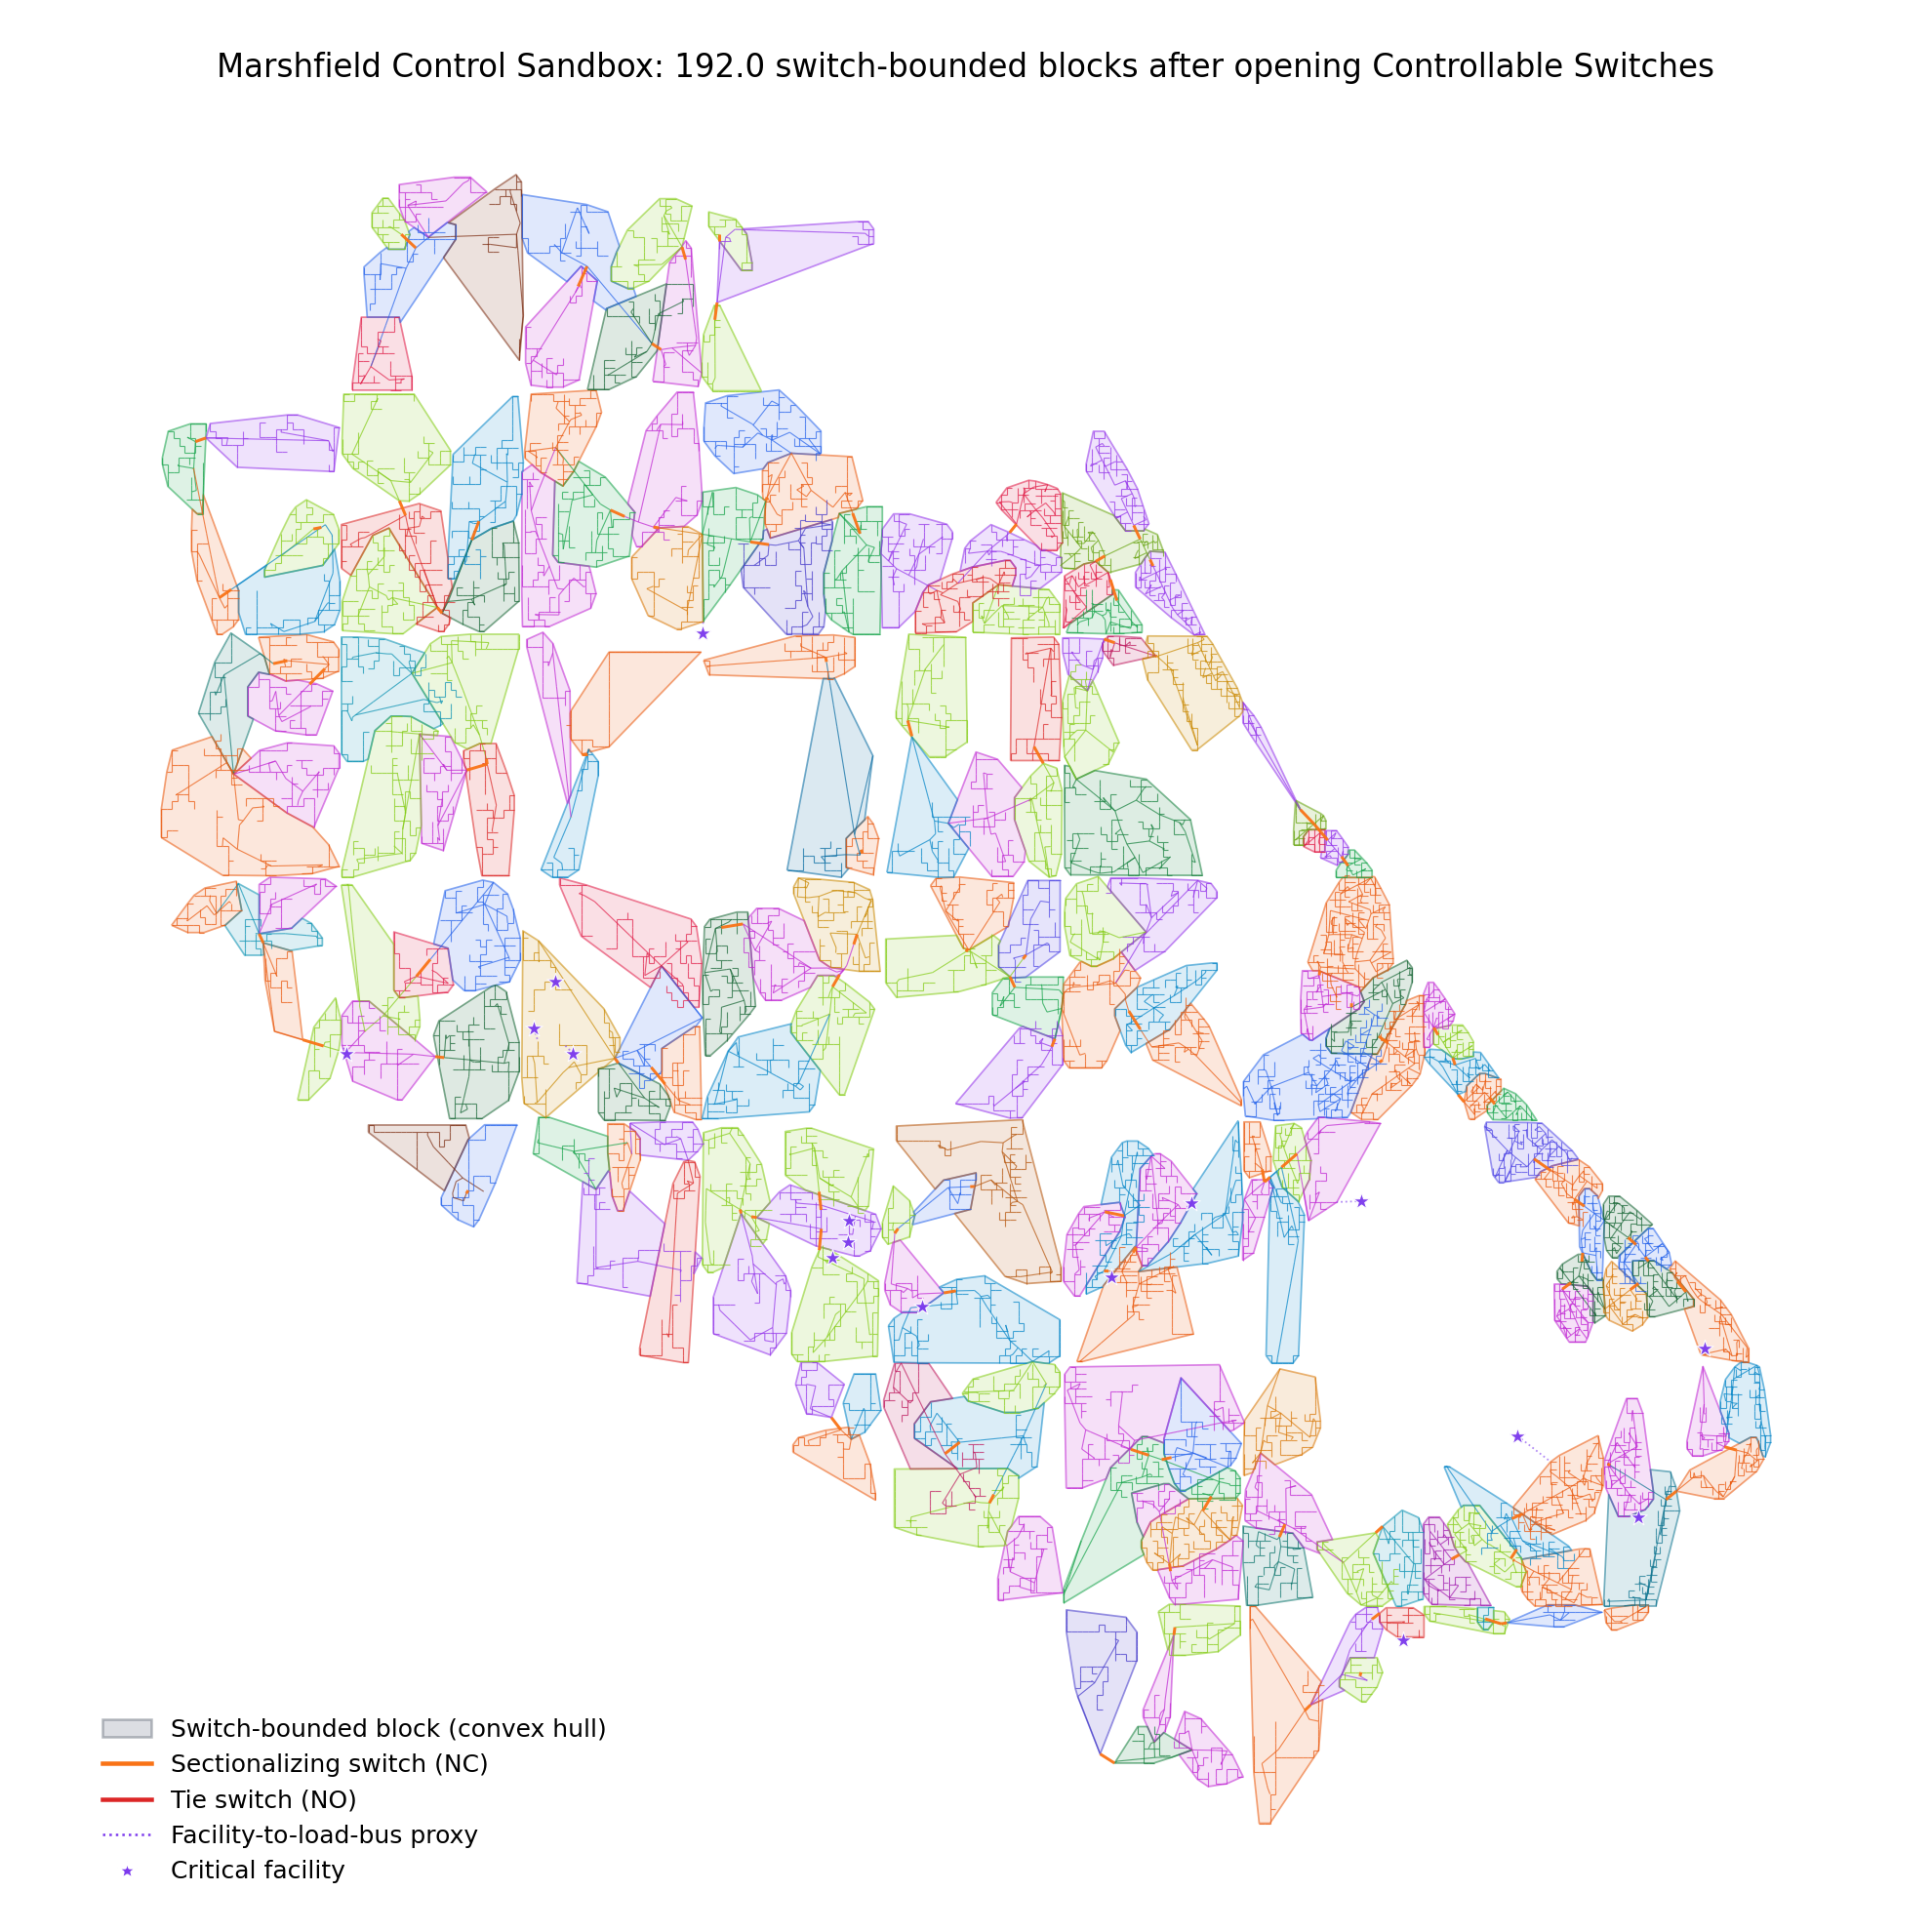

output_path /home/grahamhults/projects/Flood-RM/locations/...
switch_bounded_blocks 192
opened_existing_lines_for_blocks 150
median_block_bus_count 81.5
max_block_bus_count 314
display_block_hulls 192
block_line_segments 15837
sectionalizing_switch_segments 150
tie_switch_segments 0
zero_length_tie_ticks 0
critical_facility_segments 16
Name: location_block_overview, dtype: object

output_path /home/grahamhults/projects/Flood-RM/locations/...
selected_block_bus_members 2263
local_lines 2068
local_buses 2263
local_demand_buses 1386
local_transformers 190
local_sources 5
local_switch_markers 16
local_sectionalizing_switch_segments 16
local_tie_switch_segments 0
visible_block_hulls 21
critical_facilities_visible 3
critical_facility_proxy_segments 3
basemap_added True
Name: ocean_bluff_detail, dtype: object

In [6]:
from IPython.display import Image, display

import json
from pathlib import Path

import contextily as ctx
import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from shapely.geometry import LineString, MultiPoint, box

sectionalizing_switch_color = "#f97316"
tie_switch_color = "#dc2626"
ocean_bluff_bbox = {"min_lon": -70.666, "max_lon": -70.635, "min_lat": 42.078, "max_lat": 42.105}
webster_substation_bus = "marshfield_shift_synthetic_region_044__66050127"
block_alpha = 0.22


def _read_table(path):
    path = Path(path)
    return pd.read_parquet(path) if path.suffix == ".parquet" else pd.read_csv(path)


def _optional_table(path):
    path = Path(path)
    return _read_table(path) if path.exists() else pd.DataFrame()


def _point_gdf(df, x="lon", y="lat"):
    if df.empty or x not in df or y not in df:
        return gpd.GeoDataFrame(df.copy(), geometry=[], crs=4326)
    rows = df.dropna(subset=[x, y]).copy()
    return gpd.GeoDataFrame(rows, geometry=gpd.points_from_xy(rows[x], rows[y]), crs=4326)


def _line_gdf(df):
    required = ["from_lon", "from_lat", "to_lon", "to_lat"]
    if df.empty or any(column not in df for column in required):
        return gpd.GeoDataFrame(df.copy(), geometry=[], crs=4326)
    rows = df.dropna(subset=required).copy()
    if "has_buscoords" in rows:
        rows = rows[rows["has_buscoords"].astype(str).str.lower().eq("true")]
    rows["geometry"] = [
        LineString([(row.from_lon, row.from_lat), (row.to_lon, row.to_lat)])
        for row in rows.itertuples()
    ]
    return gpd.GeoDataFrame(rows, geometry="geometry", crs=4326)


def _asset_registry(registry_dir, compat_dir):
    registry_dir = Path(registry_dir)
    compat_dir = Path(compat_dir)
    return {
        "buses": _optional_table(registry_dir / "buses.csv"),
        "lines": _optional_table(registry_dir / "lines.csv"),
        "load_buses": _optional_table(registry_dir / "load_buses.csv"),
        "transformers": _optional_table(registry_dir / "transformers.csv"),
        "sources": _optional_table(registry_dir / "sources.csv"),
        "switches": _optional_table(compat_dir / "controllable_switches.parquet"),
        "blocks": _optional_table(compat_dir / "switch_bounded_load_blocks.parquet"),
        "facilities": _optional_table(compat_dir / "critical_facilities.parquet"),
        "assignments": _optional_table(compat_dir / "critical_load_assignments.parquet"),
    }


def _block_hulls(blocks, buses_3857):
    if blocks.empty or buses_3857.empty or "buses_json" not in blocks:
        return gpd.GeoDataFrame(geometry=[], crs=3857)
    bus_geom = buses_3857.dropna(subset=["bus"]).set_index("bus").geometry
    records = []
    for index, row in enumerate(blocks.sort_values([column for column in ["feeder_id", "block_id"] if column in blocks]).itertuples()):
        names = [name for name in json.loads(row.buses_json) if name in bus_geom.index]
        if len(names) < 3:
            continue
        geom = MultiPoint(list(bus_geom.loc[names])).convex_hull.envelope
        if not geom.is_empty:
            records.append({
                "block_id": getattr(row, "block_id", f"block_{index:04d}"),
                "feeder_id": getattr(row, "feeder_id", ""),
                "bus_count": int(getattr(row, "bus_count", len(names))),
                "load_kw": float(getattr(row, "load_kw", 0.0)),
                "color_id": index,
                "bus_names": names,
                "geometry": geom,
            })
    return gpd.GeoDataFrame(records, geometry="geometry", crs=3857) if records else gpd.GeoDataFrame(geometry=[], crs=3857)


def _switch_segments(switches, buses, lines):
    if switches.empty:
        return gpd.GeoDataFrame(geometry=[], crs=3857), 0
    bus_geom = buses.dropna(subset=["bus"]).set_index("bus").geometry
    line_key = "line_name" if "line_name" in lines else "line"
    line_geom = lines.dropna(subset=[line_key]).set_index(line_key).geometry if line_key in lines else {}
    records = []
    zero_length = 0
    for row in switches.itertuples():
        role = str(getattr(row, "switch_role", ""))
        geom = None
        if role == "sectionalizing" and bool(getattr(row, "opens_existing_line", False)):
            geom = line_geom.get(str(getattr(row, "associated_line_name", "")))
        elif role == "tie":
            left = bus_geom.get(str(getattr(row, "from_bus", "")))
            right = bus_geom.get(str(getattr(row, "to_bus", "")))
            if left is not None and right is not None:
                if left.equals(right):
                    zero_length += 1
                    geom = LineString([(left.x - 20, left.y - 20), (left.x + 20, left.y + 20)])
                else:
                    geom = LineString([left, right])
        if geom is not None and not geom.is_empty:
            records.append({**row._asdict(), "geometry": geom})
    return gpd.GeoDataFrame(records, geometry="geometry", crs=3857), zero_length


def _facility_connectors(facilities, assignments, buses):
    if facilities.empty or assignments.empty or "matched_bus" not in assignments:
        return gpd.GeoDataFrame(geometry=[], crs=3857)
    bus_geom = buses.dropna(subset=["bus"]).set_index("bus").geometry
    rows = assignments.merge(facilities.drop(columns="geometry"), on="facility_id", how="inner")
    lines = []
    for row in rows.itertuples():
        bus = bus_geom.get(str(row.matched_bus))
        facility_geom = facilities.loc[facilities["facility_id"].astype(str).eq(str(row.facility_id)), "geometry"]
        if bus is not None and not facility_geom.empty:
            lines.append({"facility_id": row.facility_id, "geometry": LineString([facility_geom.iloc[0], bus])})
    return gpd.GeoDataFrame(lines, geometry="geometry", crs=3857)


def _plot_gdf(gdf, ax, **kwargs):
    if not gdf.empty:
        gdf.plot(ax=ax, **kwargs)


def _save_figure(fig, output_path, *, dpi, pad=None):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout(**({"pad": pad} if pad is not None else {}))
    fig.savefig(output_path, dpi=dpi)
    plt.close(fig)


def _overview_legend():
    return [
        mpatches.Patch(facecolor="#9ca3af", edgecolor="#374151", alpha=0.35, label="Switch-bounded block"),
        Line2D([0], [0], color=sectionalizing_switch_color, lw=1.8, label="Sectionalizing switch (NC)"),
        Line2D([0], [0], color=tie_switch_color, lw=1.8, label="Tie switch (NO)"),
        Line2D([0], [0], color="#7c3aed", lw=1.0, ls=":", label="Facility-to-load-bus proxy"),
        Line2D([0], [0], marker="*", color="none", markerfacecolor="#7c3aed", markeredgecolor="white", markersize=8, label="Critical facility"),
    ]


def _detail_legend():
    return [
        mpatches.Patch(facecolor="#9ca3af", edgecolor="#374151", alpha=block_alpha, label="Switch-bounded block hull"),
        Line2D([0], [0], color="#4b5563", lw=1.6, label="Distribution line"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor="#111827", alpha=0.55, markersize=4, label="Bus"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor="#2563eb", markersize=5, label="Demand bus"),
        Line2D([0], [0], marker="D", color="none", markerfacecolor="#ca8a04", markeredgecolor="white", markersize=7, label="Transformer"),
        Line2D([0], [0], color=sectionalizing_switch_color, lw=2.0, label="Sectionalizing switch (NC)"),
        Line2D([0], [0], color=tie_switch_color, lw=2.2, label="Tie switch (NO)"),
        Line2D([0], [0], marker="s", color="none", markerfacecolor="#ef4444", markeredgecolor="white", markersize=6, label="Switch point"),
        Line2D([0], [0], marker="^", color="none", markerfacecolor="#111827", markeredgecolor="white", markersize=9, label="Source"),
        Line2D([0], [0], color="#7c3aed", lw=1.0, ls=":", label="Facility-to-load-bus proxy"),
        Line2D([0], [0], marker="*", color="none", markerfacecolor="#7c3aed", markeredgecolor="white", markersize=11, label="Critical facility"),
        Line2D([0], [0], marker="^", color="none", markerfacecolor="#f59e0b", markeredgecolor="#111827", markersize=11, label="Eversource Webster Substation"),
    ]


artifacts = _asset_registry(grid["asset_registry"], grid["augmented_artifacts"])
buses = _point_gdf(artifacts["buses"]).to_crs(3857)
lines = _line_gdf(artifacts["lines"]).to_crs(3857)
switches = _point_gdf(artifacts["switches"]).to_crs(3857)
facilities = _point_gdf(artifacts["facilities"]).to_crs(3857)
blocks = _block_hulls(artifacts["blocks"], buses)
switch_lines, zero_length = _switch_segments(switches, buses, lines)
connectors = _facility_connectors(facilities, artifacts["assignments"], buses)

block_overview_path = grid["figures"] / "switch_bounded_blocks.png"
fig, ax = plt.subplots(figsize=(11, 11))
_plot_gdf(blocks, ax, column="color_id", cmap="tab20", alpha=0.25, edgecolor="#374151", linewidth=0.5)
_plot_gdf(lines, ax, color="#4b5563", linewidth=0.35, alpha=0.45)
if not switch_lines.empty:
    switch_lines.plot(
        ax=ax,
        color=switch_lines["switch_role"].map({"sectionalizing": sectionalizing_switch_color, "tie": tie_switch_color}),
        linewidth=1.2,
        alpha=0.95,
    )
_plot_gdf(connectors, ax, color="#7c3aed", linewidth=0.7, alpha=0.6, linestyle=":")
_plot_gdf(facilities, ax, color="#7c3aed", marker="*", markersize=52, edgecolor="white", linewidth=0.45)
ax.set_title(f"Grid Dataset: {len(blocks):.1f} switch-bounded blocks after opening Controllable Switches", fontsize=13)
ax.axis("off")
ax.legend(handles=_overview_legend(), loc="lower left", frameon=False)
_save_figure(fig, block_overview_path, dpi=180)

block_sizes = blocks["bus_count"] if "bus_count" in blocks else pd.Series(dtype=float)
block_overview_report = {
    "output_path": str(block_overview_path),
    "switch_bounded_blocks": int(len(blocks)),
    "opened_existing_lines_for_blocks": int(artifacts["switches"].get("opens_existing_line", pd.Series(dtype=bool)).fillna(False).sum()) if not artifacts["switches"].empty else 0,
    "median_block_bus_count": float(block_sizes.median()) if not block_sizes.empty else 0.0,
    "max_block_bus_count": int(block_sizes.max()) if not block_sizes.empty else 0,
    "display_block_hulls": len(blocks),
    "block_line_segments": len(lines),
    "sectionalizing_switch_segments": int((switch_lines["switch_role"] == "sectionalizing").sum()) if not switch_lines.empty else 0,
    "tie_switch_segments": int((switch_lines["switch_role"] == "tie").sum()) if not switch_lines.empty else 0,
    "zero_length_tie_ticks": zero_length,
    "critical_facility_segments": len(connectors),
}

clip_geom = gpd.GeoSeries([box(ocean_bluff_bbox["min_lon"], ocean_bluff_bbox["min_lat"], ocean_bluff_bbox["max_lon"], ocean_bluff_bbox["max_lat"])], crs=4326).to_crs(3857).iloc[0]
loads = _point_gdf(artifacts["load_buses"]).to_crs(3857)
transformers = _point_gdf(artifacts["transformers"], "location_lon", "location_lat").to_crs(3857)
sources = _point_gdf(artifacts["sources"]).to_crs(3857)
detail_blocks = blocks.clip(clip_geom) if not blocks.empty else blocks
if detail_blocks.empty:
    raise RuntimeError(f"No switch-bounded load blocks intersect {ocean_bluff_bbox}.")
selected_buses = set(np.concatenate(detail_blocks["bus_names"].to_numpy()))
local_buses = buses[buses["bus"].isin(selected_buses)]
local_loads = loads[loads["bus"].isin(selected_buses)] if "bus" in loads else loads.clip(clip_geom)
local_lines = lines[lines["from_bus"].isin(selected_buses) & lines["to_bus"].isin(selected_buses)] if {"from_bus", "to_bus"} <= set(lines.columns) else lines.clip(clip_geom)
local_sources = sources[sources["bus"].isin(selected_buses)] if "bus" in sources else sources.clip(clip_geom)
local_transformers = transformers.clip(clip_geom) if not transformers.empty else transformers
local_switches = switches.clip(clip_geom) if not switches.empty else switches
local_facilities = facilities.clip(clip_geom) if not facilities.empty else facilities
local_connectors = _facility_connectors(local_facilities, artifacts["assignments"], local_buses)
local_connectors = local_connectors.clip(clip_geom) if not local_connectors.empty else local_connectors
local_switch_lines, _ = _switch_segments(local_switches, local_buses, local_lines)
plot_extent = detail_blocks.geometry.unary_union.envelope.buffer(120)
minx, miny, maxx, maxy = plot_extent.bounds

fig, ax = plt.subplots(figsize=(10, 11))
ax.set_facecolor("#eef2f3")
try:
    ctx.add_basemap(ax, crs=3857, source=ctx.providers.CartoDB.PositronNoLabels)
    basemap_added = True
except Exception:
    basemap_added = False
_plot_gdf(detail_blocks, ax, column="color_id", cmap="tab20", alpha=block_alpha, edgecolor="k", linewidth=0.8)
_plot_gdf(local_lines, ax, color="#4b5563", linewidth=0.58, alpha=0.70)
if not local_switch_lines.empty:
    local_switch_lines.plot(
        ax=ax,
        color=local_switch_lines["switch_role"].map({"sectionalizing": sectionalizing_switch_color, "tie": tie_switch_color}).fillna("#ef4444"),
        linewidth=1.9,
        alpha=0.96,
    )
_plot_gdf(local_buses, ax, color="#111827", markersize=1.0, alpha=0.36)
_plot_gdf(local_loads, ax, color="#2563eb", markersize=5.0, alpha=0.78)
_plot_gdf(local_transformers, ax, color="#ca8a04", marker="D", markersize=22, edgecolor="white")
if not local_switches.empty:
    local_switches.plot(ax=ax, color=local_switches["switch_role"].map({"sectionalizing": sectionalizing_switch_color, "tie": tie_switch_color}).fillna("#ef4444"), marker="s", markersize=18, edgecolor="white")
_plot_gdf(local_connectors, ax, color="#7c3aed", linewidth=0.85, alpha=0.62, linestyle=":")
_plot_gdf(local_facilities, ax, color="#7c3aed", marker="*", markersize=86, edgecolor="white")
if "bus" in local_sources:
    _plot_gdf(local_sources[~local_sources["bus"].eq(webster_substation_bus)], ax, color="#111827", marker="^", markersize=72, edgecolor="white")
    _plot_gdf(local_sources[local_sources["bus"].eq(webster_substation_bus)], ax, color="#f59e0b", marker="^", markersize=135, edgecolor="#111827")
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.axis("off")
ax.set_title(
    "Ocean Bluff and Brant Rock\n"
    f"{len(detail_blocks):,} blocks | {len(local_lines):,} lines\n"
    f"{len(local_buses):,} buses | {len(local_loads):,} demand buses\n"
    f"{len(local_transformers):,} transformers | {len(local_switches):,} switch points | {len(local_facilities):,} critical facilities",
    fontsize=10.5,
)
legend = ax.legend(handles=_detail_legend(), loc="upper right", frameon=True, fontsize=8.8)
legend.get_frame().set_facecolor("white")
legend.get_frame().set_alpha(0.88)
if basemap_added:
    ax.text(0.01, 0.01, "Basemap: OpenStreetMap contributors, CARTO no-label tiles", transform=ax.transAxes, fontsize=6.5, color="#6b7280")
ocean_bluff_path = grid["figures"] / "ocean_bluff" / "ocean_bluff_network_components.png"
_save_figure(fig, ocean_bluff_path, dpi=240, pad=0.3)

ocean_bluff_detail = {
    "output_path": str(ocean_bluff_path),
    "selected_block_bus_members": len(selected_buses),
    "local_lines": len(local_lines),
    "local_buses": len(local_buses),
    "local_demand_buses": len(local_loads),
    "local_transformers": len(local_transformers),
    "local_sources": len(local_sources),
    "local_switch_markers": len(local_switches),
    "local_sectionalizing_switch_segments": int((local_switch_lines["switch_role"] == "sectionalizing").sum()) if not local_switch_lines.empty else 0,
    "local_tie_switch_segments": int((local_switch_lines["switch_role"] == "tie").sum()) if not local_switch_lines.empty else 0,
    "visible_block_hulls": len(detail_blocks),
    "critical_facilities_visible": len(local_facilities),
    "critical_facility_proxy_segments": len(local_connectors),
    "basemap_added": basemap_added,
}

display(Image(filename=block_overview_report["output_path"]))
display(pd.Series(block_overview_report, name="location_block_overview"))
display(Image(filename=ocean_bluff_detail["output_path"]))
display(pd.Series(ocean_bluff_detail, name="ocean_bluff_detail"))
